In [1]:
!pip install transformers datasets rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e78c2291ed608b6631e54a2b93c52f0e61b5f300ce9a8555423f0fae4bb7fbc3
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

In [3]:
models = ["gpt2", "distilgpt2", "EleutherAI/gpt-neo-125M"]
prompt = "Once upon a time in a futuristic world,"

In [4]:
results = []

In [ ]:

for model_name in models:
    print(f"Evaluating {model_name}...")


    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)


    model_size = sum(p.numel() for p in model.parameters()) * 4 / (1024**2)


    inputs = tokenizer(prompt, return_tensors="pt")


    start_time = time.time()
    outputs = model.generate(**inputs, max_new_tokens=50)
    end_time = time.time()
    inference_time = end_time - start_time


    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)


    with torch.no_grad():
        logits = model(**inputs).logits
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = inputs["input_ids"][..., 1:].contiguous()
        loss_fct = torch.nn.CrossEntropyLoss()
        loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
        perplexity = torch.exp(loss).item()


    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_score = scorer.score(prompt, generated_text)['rougeL'].fmeasure


    results.append({
        "Model": model_name,
        "Perplexity": perplexity,
        "InferenceTime": inference_time,
        "ModelSize": model_size,
        "ROUGE": rouge_score
    })


In [6]:

df = pd.DataFrame(results)
df




,Model,Perplexity,InferenceTime,ModelSize,ROUGE
0,gpt2,35.788368,2.692599,474.700195,0.262295
1,distilgpt2,68.225822,1.683583,312.471680,0.640000
2,EleutherAI/gpt-neo-125M,30.376886,2.333176,477.594727,0.258065


In [7]:

weights = [0.3, 0.2, 0.2, 0.3]
impacts = ['-', '-', '-', '+']


data = df.iloc[:, 1:].values.astype(float)
norm_data = data / np.sqrt((data**2).sum(axis=0))


weighted_data = norm_data * weights


ideal_best = np.max(weighted_data, axis=0)
ideal_worst = np.min(weighted_data, axis=0)

for i, impact in enumerate(impacts):
    if impact == '-':
        ideal_best[i], ideal_worst[i] = ideal_worst[i], ideal_best[i]


distance_best = np.sqrt(((weighted_data - ideal_best)**2).sum(axis=1))
distance_worst = np.sqrt(((weighted_data - ideal_worst)**2).sum(axis=1))


topsis_score = distance_worst / (distance_best + distance_worst)
df['TOPSIS Score'] = topsis_score
df['Rank'] = df['TOPSIS Score'].rank(ascending=False)

df


,Model,Perplexity,InferenceTime,ModelSize,ROUGE,TOPSIS Score,Rank
0,gpt2,35.788368,2.692599,474.700195,0.262295,0.410525,3.0
1,distilgpt2,68.225822,1.683583,312.471680,0.640000,0.552654,1.0
2,EleutherAI/gpt-neo-125M,30.376886,2.333176,477.594727,0.258065,0.456331,2.0


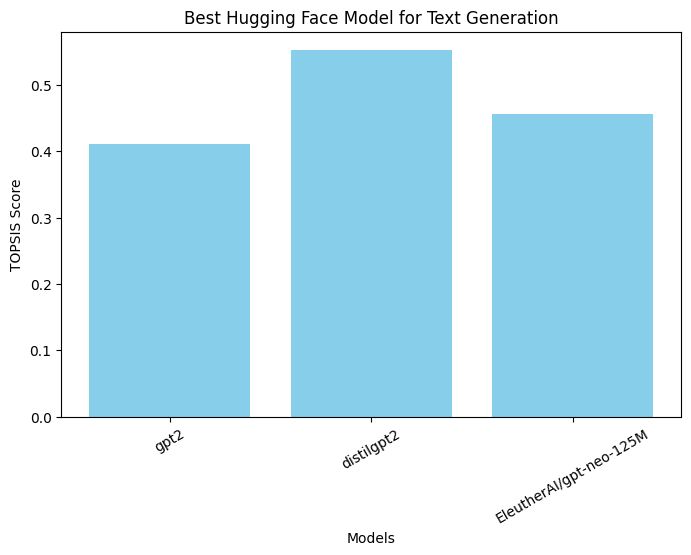

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:

plt.figure(figsize=(8,5))
plt.bar(df['Model'], df['TOPSIS Score'], color='skyblue')
plt.xlabel("Models")
plt.ylabel("TOPSIS Score")
plt.title("Best Hugging Face Model for Text Generation")
plt.xticks(rotation=30)


plot_filename = "topsis_huggingface_plot.png"
plt.savefig(plot_filename)

plt.show()

from google.colab import files
files.download(plot_filename)



In [9]:

df.to_csv("topsis_huggingface_results.csv", index=False)
